# 5. Non-Linear Regression

:::{admonition} Course Website 
http://54.243.252.9/ce-5319-webroot/ 
:::

Usually, this would remain part of "optimization" chapter, but in my opinion, while NLP regression is heavily influenced by optimization methods, it deserves its own discourse.

## Readings/References

1. [Burkov, A. (2019) The One Hundred Page Machine Learning Book](http://ema.cri-info.cm/wp-content/uploads/2019/07/2019BurkovTheHundred-pageMachineLearning.pdf) Required Textbook

2. [Rashid, Tariq. (2016) Make Your Own Neural Network. Kindle Edition. ](https://www.goodreads.com/en/book/show/29746976-make-your-own-neural-network) Required Textbook

## Videos

:::{warning}
This section is under development, so it will have sections that appear disjointed and/or missing examples.
:::

Non-Linear Regression and Constrained Optimization.

Non-linear regression problems often require minimizing a loss function (typically squared error) when the relationship between predictors and response is not linear. In low-dimensional settings, classic *unconstrained* methods like Nelder-Mead, Powell’s direction set, and Hooke and Jeeves are useful starting points.

However, real-world problems frequently involve constraints. These can include:

1. Box constraints (e.g., parameter bounds),

2. Equality constraints (e.g., parameter sum must equal a constant),

3. Inequality constraints (e.g., parameter A must exceed parameter B),

4. or constraints derived from physical principles, such as conservation laws or design requirements.

:::{admonition} A quick Aside - Solving systems of non-linear equations
Much of this subsection is lifted from [Numerical Recipes pp 372-376](http://54.243.252.9/engr-1330-webroot/3-Readings/NumericalRecipesinF77.pdf)

**Newton-Raphson Method for Nonlinear Systems of Equations**
...
Consider the case of two dimensions, where we want to solve simultaneously

$f(x, y) = 0$ and <br>
$g(x, y) = 0$

The functions $f$ and $g$ are two arbitrary functions, each of which has zero contour lines (level sets) that divide the $(x, y)$ plane into regions where their respective function is positive or negative. 

> ![](nonlinearequations.png)
> 
> Figure from Numerical Recipes

These zero contour boundaries are of interest to us. The solutions that we seek are those points (if any) that are common to the zero contours
of $f$ and $g$. Unfortunately, the functions $f$ and $g$ have, in general, no relation to each other at all! There is nothing special about a common point from either $f$’s point of view, or from $g$’s. In order to find all common points, which are the solutions of our nonlinear equations, we will (in general) have to more or less map out the full zero contours of both functions. 
Note further that the zero contours will (in general) consist of an unknown number of disjoint closed curves. It seems hopeless to think we have found all such disjoint pieces.  (Method of Darts anyone?)

For problems in more than two dimensions, we need to find points mutually common to $N$ unrelated zero-contour hypersurfaces, each of dimension $N − 1$

... such root finding is virtually impossible without **insight** ...

... the simplest multidimensional root finding method, Newton-Raphson. This method gives you a very efficient means of converging to a root, if you have a sufficiently good *initial guess*

...

Suffice to say solving systems of non-linear equations is hard, unless you already know the answer - so why does it work for things like pipeline networks?  In pipeline networks (and similar types of networks where there is a flow and related driving force), the nonlinearity is mild, and we already know that energy variables must lie between zero and the highest head in the system. This bounded structure gives us just enough information to make root-finding practical.

The temptation to embed the system of equations directly into the constraint set of a nonlinear optimizer is strong—and in some cases, it might even succeed. But more often, even when real solutions exist, the optimizer may get hopelessly stuck, especially without the kind of structural insight that makes root-finding feasible in simpler cases like pipeline networks.  Now reexamine the four constraint conditions listed above—notice that the last one is constraints derived from physical principles, such as conservation laws or design requirements. This is exactly what we mean by insight, and it's essential to making these methods work in practice.
:::

## Methods Employed

The introduction of constraints shifts the solution from merely "best fitting" to "best fitting under permissible scenarios" — a crucial distinction in engineering and applied science.

Common approaches:

1. Penalty methods: Add a term to the objective function that heavily penalizes constraint violations.

2. Sequential quadratic programming (SQP): Solves a series of quadratic approximations.

3. SLSQP (Sequential Least Squares Quadratic Programming): Available via scipy.optimize.minimize.

## Python Example: Constrained Non-Linear Fit
Let’s demonstrate a constrained non-linear regression problem using scipy.optimize.minimize:

Example: Fitting a simple exponential decay with bounds and a constraint

Optimized Parameters: [2.14620329 1.51239471]
Constraint satisfied: True


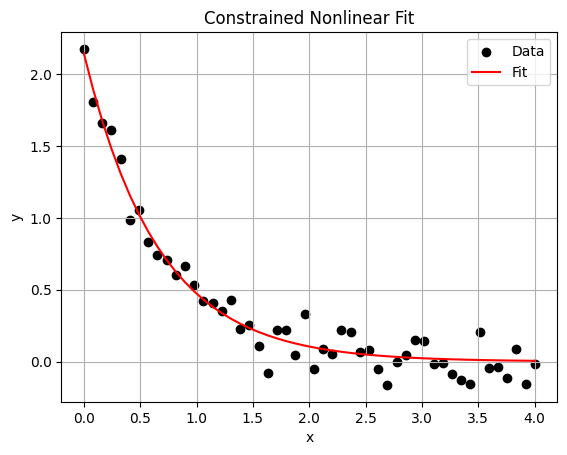

In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Simulated data
np.random.seed(0)
x_data = np.linspace(0, 4, 50)
true_params = [2.0, 1.5]
y_data = true_params[0] * np.exp(-true_params[1] * x_data) + 0.1 * np.random.normal(size=x_data.shape)

# Model function
def model(x, params):
    return params[0] * np.exp(-params[1] * x)

# Objective function: Sum of Squared Errors (SSE)
def objective(params):
    return np.sum((y_data - model(x_data, params))**2)

# Non-negativity and upper bound constraints on parameters
bounds = [(0.1, 5.0), (0.1, 3.0)]

# Constraint: param[0] + param[1] <= 4.0
def constraint_sum(p):
    return 4.0 - (p[0] + p[1])

con = {'type': 'ineq', 'fun': constraint_sum}

# Initial guess
x0 = [1.0, 1.0]

# Solve
result = minimize(objective, x0, bounds=bounds, constraints=[con], method='SLSQP')

# Display results
print("Optimized Parameters:", result.x)
print("Constraint satisfied:", constraint_sum(result.x) >= 0)

# Plot fit
plt.scatter(x_data, y_data, label="Data", color='black')
plt.plot(x_data, model(x_data, result.x), label="Fit", color='red')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Constrained Nonlinear Fit")
plt.grid(True)
plt.show()

## Transitioning to Larger Datasets
Introduce scaling issues: Emphasize computational cost of gradient-free methods.

Highlight benefit of gradient-aware optimizers: Like L-BFGS-B, which is often preferable for larger models.

Introduce practical applications:

Parameter calibration in groundwater flow models,

Fitting reaction kinetics in environmental systems,

Multi-parameter regression in transportation or hydrology.

## Penalty Method for Constrained Nonlinear Regression

Instead of directly imposing constraints via `scipy.optimize.minimize`, we embed the constraint into the objective function by adding a penalty term that grows when the constraint is violated.

We'll use the same exponential model as before:

## Python Example: Penalizing Violation of Sum Constraint

Optimized Parameters (with penalty): [2.14595176 1.5123388 ]
Constraint violation: 0


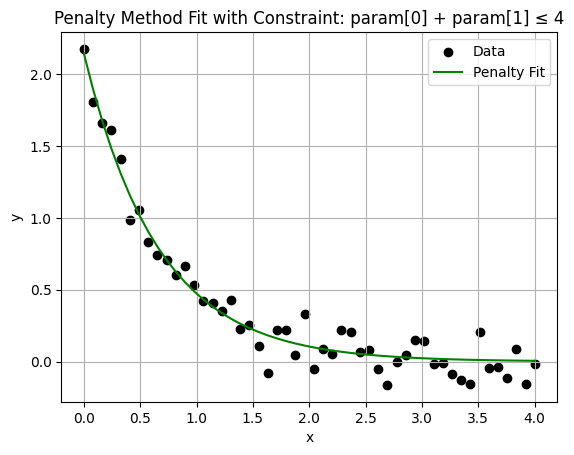

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Data generation
np.random.seed(0)
x_data = np.linspace(0, 4, 50)
true_params = [2.0, 1.5]
y_data = true_params[0] * np.exp(-true_params[1] * x_data) + 0.1 * np.random.normal(size=x_data.shape)

# Model function
def model(x, params):
    return params[0] * np.exp(-params[1] * x)

# Penalty weight (adjust this as needed)
penalty_weight = 1e3

# Define constraint function: param[0] + param[1] <= 4.0
def constraint_violation(p):
    return max(0, p[0] + p[1] - 4.0)

# Penalized objective
def penalized_objective(params):
    error = np.sum((y_data - model(x_data, params))**2)
    penalty = penalty_weight * constraint_violation(params)**2
    return error + penalty

# Initial guess
x0 = [1.0, 1.0]

# Minimize (no bounds this time, to emphasize penalty effect)
result = minimize(penalized_objective, x0, method='Powell')  # You can swap with Nelder-Mead or others

# Show results
print("Optimized Parameters (with penalty):", result.x)
print("Constraint violation:", constraint_violation(result.x))

# Plot result
plt.scatter(x_data, y_data, label="Data", color='black')
plt.plot(x_data, model(x_data, result.x), label="Penalty Fit", color='green')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Penalty Method Fit with Constraint: param[0] + param[1] ≤ 4")
plt.legend()
plt.grid(True)
plt.show()

Why use penalty methods?

- Work with any optimizer (even those not built for constraints).
- Easy to extend for multiple constraints.
- Lets one see the effect of tuning the penalty weight (penalty_weight) on the result.

Tradeoffs:
- Too small → constraint gets ignored.
- Too large → may dominate the objective and cause poor convergence.
